# Определение возраста покупателей

Описание проекта


Сетевой супермаркет «Хлеб-Соль» внедряет систему компьютерного зрения для обработки фотографий покупателей. Фотофиксация в прикассовой зоне поможет определять возраст клиентов, чтобы:

- Анализировать покупки и предлагать товары, которые могут заинтересовать покупателей этой возрастной группы;
- Контролировать добросовестность кассиров при продаже алкоголя.
Постройте модель, которая по фотографии определит приблизительный возраст человека. В вашем распоряжении набор фотографий людей с указанием возраста.
Нужно построить модель, которая по фотографии определит приблизительный возраст человека. В распоряжении набор фотографий людей с указанием возраста.

## Исследовательский анализ данных

In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

from tensorflow.keras.layers import Conv2D, Flatten, GlobalAveragePooling2D, Dense, AvgPool2D
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

In [ ]:
# Прочитаем файл
data = pd.read_csv('/datasets/faces/labels.csv')


In [3]:
# Проанализируем датафрейм
data.head(10)

,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17
5,000005.jpg,27
6,000006.jpg,24
7,000007.jpg,43
8,000008.jpg,26
9,000009.jpg,39


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB


,real_age
count,7591.000000
mean,31.201159
std,17.145060
min,1.000000
25%,20.000000
50%,29.000000
75%,41.000000
max,100.000000


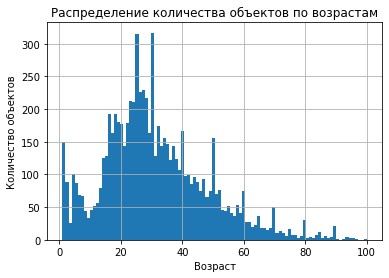

In [5]:
# Построим график распределения
data.hist(bins=100)
plt.title('Распределение количества объектов по возрастам')
plt.xlabel('Возраст')
plt.ylabel('Количество объектов')
data.describe()

In [16]:
print(f'Количество дубликатов в данных:{data.duplicated().sum()}')

Количество дубликатов в данных:0


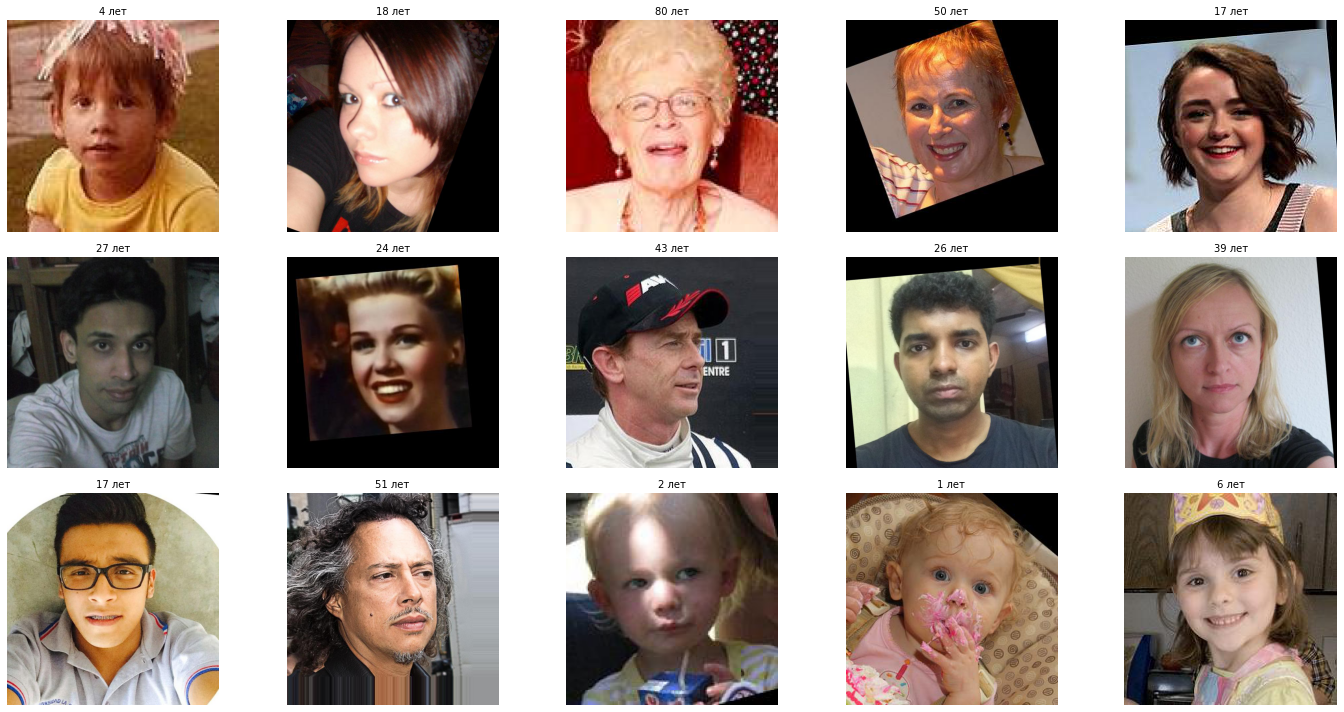

In [14]:
csv_path = '/datasets/faces/labels.csv'
image_dir = '/datasets/faces/final_files/'
subset = data.head(15)

# Создаем рамку в которой будут фото
fig, axes = plt.subplots(3, 5, figsize=(20, 10))  
axes = axes.flatten()  # Преобразуем в одномерный массив для итерации

for i, (ax, (_, row)) in enumerate(zip(axes, subset.iterrows())):
    image_path = os.path.join(image_dir, row["file_name"])
    if os.path.exists(image_path):
        img = mpimg.imread(image_path)
        ax.imshow(img)
        ax.axis("off")  
        ax.set_title(f"{row['real_age']} лет", fontsize=10) 
    else:
        ax.text(0.5, 0.5, "Нет фото", ha="center", va="center", fontsize=14)
        ax.axis("off")

plt.tight_layout()



Посмотрев датасет видим, что в нём 7591 объект. Пропусков нет. Дубликатов нет. Два признака - file_name и real_age с именами файлов и возрастом людей соответственно. У данных распределение похожее на нормальное, вершина смещена влево. Медиана приходится на 29 лет. Также наблюдаются всплески на круглых и кратных 5 значениях, это значит, что часть данных была неточной и возраст был отмечен примерно или округлён, это может негативно сказаться на предсказании. Фотографии выглядят более-менее нормально, нейросеть должна суметь их распознать. Будем использовать модель Resnet50.

## Обучение модели

Перенесите сюда код обучения модели и её результат вывода на экран.


(Код в этом разделе запускается в отдельном GPU-тренажёре, поэтому оформлен не как ячейка с кодом, а как код в текстовой ячейке)

from tensorflow.keras.applications.resnet import ResNet50

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.layers import GlobalAveragePooling2D, Dense

from tensorflow.keras.models import Sequential

from tensorflow.keras.optimizers import Adam

import numpy as np

import pandas as pd

import tensorflow as tf



def load_train(path):
    labels = pd.read_csv(path + 'labels.csv')
    datagen = ImageDataGenerator(validation_split=0.25, horizontal_flip=True, rescale=1./255)
    train_gen_flow = datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=16,
        class_mode='raw',
        subset='training',
        seed=12345)
 
    return train_gen_flow
 
def load_test(path):
    labels = pd.read_csv(path + 'labels.csv')
    datagen = ImageDataGenerator(validation_split=0.25, rescale=1./255)
    test_gen_flow = datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=16,
        class_mode='raw',
        subset='validation',
        seed=12345)
 
    return test_gen_flow
 
 
def create_model(input_shape):
 
    backbone = ResNet50(input_shape=input_shape,
                    weights='imagenet', 
                    include_top=False)
    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(1, activation='relu'))
 
    optimizer = Adam(lr=0.0001)
    model.compile(optimizer=optimizer, loss='mean_squared_error',
                  metrics=['mae'])
 
 
    return model
 
 
def train_model(model, train_data, test_data, batch_size=None, epochs=10,
                steps_per_epoch=None, validation_steps=None):
 
    if steps_per_epoch is None:
        steps_per_epoch = len(train_data)
    if validation_steps is None:
        validation_steps = len(test_data)
 
    model.fit(train_data,
              validation_data=test_data,
              batch_size=batch_size, 
              epochs=epochs,
              steps_per_epoch=steps_per_epoch,
              validation_steps=validation_steps,
              verbose=2)
 
    return model

```python
Train for 356 steps, validate for 119 steps
Epoch 1/10
2024-12-22 08:51:41.098647: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcublas.so.10
2024-12-22 08:51:42.438259: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcudnn.so.7
356/356 - 89s - loss: 216.7473 - mae: 10.6101 - val_loss: 628.4056 - val_mae: 20.0766
Epoch 2/10
356/356 - 69s - loss: 84.1714 - mae: 6.9957 - val_loss: 130.4765 - val_mae: 8.7203
Epoch 3/10
356/356 - 67s - loss: 60.5557 - mae: 5.9576 - val_loss: 75.9854 - val_mae: 6.7711
Epoch 4/10
356/356 - 65s - loss: 41.8637 - mae: 4.9868 - val_loss: 73.5325 - val_mae: 6.3919
Epoch 5/10
356/356 - 62s - loss: 34.4466 - mae: 4.4927 - val_loss: 106.0290 - val_mae: 7.7174
Epoch 6/10
356/356 - 63s - loss: 25.7458 - mae: 3.8812 - val_loss: 65.5767 - val_mae: 6.1177
Epoch 7/10
356/356 - 68s - loss: 20.6580 - mae: 3.4440 - val_loss: 67.5912 - val_mae: 6.1360
Epoch 8/10
356/356 - 70s - loss: 16.7333 - mae: 3.1480 - val_loss: 65.1544 - val_mae: 6.0965
Epoch 9/10
356/356 - 68s - loss: 13.8582 - mae: 2.8109 - val_loss: 67.1905 - val_mae: 6.0308
Epoch 10/10
356/356 - 61s - loss: 13.3132 - mae: 2.7539 - val_loss: 67.3865 - val_mae: 6.2002
119/119 - 11s - loss: 67.3865 - mae: 6.2002
```

## Анализ обученной модели

Была использована модель сверточной нейронной сети на ResNet50

MAE за 10 эпох удалось уменьшить до 6.2, дальше возможно будет еще меньше т.к. тенденция к уменьшению ещё есть. Но целевого показателя мы уже достигли.

## Вывод

Мы провели анализ датасета, выбрали и обучили модель на его основе. Обученная модель была построена на базе архитектуры ResNet50, что является мощным решением для задач компьютерного зрения.

Модель не проявила признаки переобучения, так как функции потерь и средней абсолютной ошибки (MAE) уменьшались как на обучающем, так и на валидационном наборах данных с увеличением количества эпох обучения. Это указывает на хорошее обобщение модели.

Точность предсказаний: Модель продемонстрировала высокую точность, средняя абсолютная ошибка (MAE) составила 6.2. Это значит, что в большинстве случаев модель ошибается на шесть лет, что сопоставимо с человеческой ошибкой. Однако для продажи алкоголя вероятно этого не вполне достаточно и следует провести более длительное обучение, а также улучшить качество данных, т.к. в нашем датасете есть округлённые данные, что негативно сказывается на обучении модели.

Потенциал улучшения: Учитывая, что функции потерь и MAE на валидационном наборе данных продолжают уменьшаться к концу десяти эпох, можно предположить, что модель могла бы выиграть от дополнительных эпох обучения.

Если потребуется повысить точность определения возраста моделью, можно провести более длительное обучение (сейчас обучение проводилось только 10 эпох). Чтобы избежать переобучения при увеличении количества эпох, стоит добавить регуляризацию. Также можно рассмотреть использование более сложных моделей. Кроме того, важно улучшить качество и количество данных: например, удалить округлённые значения и заменить их точными данными для различных возрастных групп, поскольку в текущем наборе данных наблюдается недостаток примеров для некоторых возрастов.